<a href="https://colab.research.google.com/github/fargonemaciel/infnet-machine-learning-codes/blob/main/model_lifecycle_fargone_maciel_flor_DR1_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Inteligência Artificial: Model LifeCycle [26E1_1]


### Teste de Performance - TP2 [OBRIGATÓRIO]

Preparação do Conjunto de Dados

**Exercício 1**: Escreva uma função chamada preparar_dataset_sklearn, a qual recebe como parâmetro um dos Conjunto de Dados (datasets) do sklearn e retorna um DataFrame pandas onde a última coluna é o target e as demais colunas são os atributos.

**Exercício 2**: Considere uma versão modificada da função do Exercício 1 chamada preparar_dataset. Assuma que tal função também pode receber um arquivo csv, ao invés de um dataset sklearn, como entrada. Responda as questões abaixo:

Quais os parâmetros da função preparar_dataset? Justifique sua resposta.
Descreva os passos executados pela função até retornar o DataFrame.

Construção de Classificador K-NN

**Exercício 3**: Escreva uma função chamada construir_classificador_knn. A função recebe um DataFrame pandas contendo o Conjunto de Dados obtido do Exercício 1, o valor do parâmetro K do K-NN e o tamanho do conjunto de treinamento em porcentagem. A função retorna um modelo classificador K-NN treinado e pronto para realizar previsões e o conjunto de teste.

**Exercício 4**: Considere uma versão modificada da função do Exercício 3 chamada construir_classificador. Considere também que existem diversos outros métodos de Classificação para Aprendizagem de Máquina diferentes do K-NN e que cada método possui diferentes parâmetros em quantidades diferentes. Um dos parâmetros da função construir_classificador é uma string contendo o tipo de classificador. Responda as questões abaixo:

Quais os parâmetros da função construir_classificador? Indique na sua resposta como você resolveria o problema de cada classificador possuir parâmetros diferentes.
Descreva os passos executados pela função até retornar o modelo Classificador.

Avaliação de Classificador K-NN

**Exercício 5**:Escreva uma função chamada avaliar_acuracia_knn. A função recebe um modelo K-NN treinado a partir da função implementada no Exercício 3, um conjunto de teste e um valor N de repetições como entrada e retorna a médias das acurácias para N repetições como saída.

**Exercício 6**: A função avaliar_acuracia_knn poderia avaliar de maneira eficaz um Regressor K-NN? Justifique sua resposta.

Previsões e Avaliação com Classificador K-NN

**Exercício 7**: Utilize as três funções implementadas no Exercício 1, Exercício 3 e Exercício 5 para avaliar a acurácia média para um mínimo de 1000 repetições dos datasets wine e breast_cancer do sklearn. Apresente o gráfico Elbow para cada dataset.

**Exercício 8**: Responda as questões abaixo:

Qual valor de K melhor prevê o tipo de cancer? Justifique sua resposta.
Qual valor de K melhor prevê o tipo de vinho? Justifique sua resposta.
Regressão com K-NN

**Exercício 9**: Considere o conjunto de dados auto-mpg do arquivo auto-mpg.csv, o qual está contido no Link 1 abaixo (para mais informações sobre o dataset acesse o Link 2 abaixo). Este dataset contém exemplos de atributos de veículos e o consumo de combustível como classe. Construa um Modelo Regressor K-NN para prever o consumo de combustível de um veículo medido em milhas por galão (mpg).

Obs.: Não utilize o atributo que contém os nomes dos veículos no seu modelo.

Link 1: https://github.com/professortiagoinfnet/inteligencia_artificial_model_lifecycle/tree/main/auto%2Bmpg
Link 2: https://archive.ics.uci.edu/dataset/9/auto+mpg

Avaliação de Regressor K-NN

**Exercício 10**: Avalie o desempenho do algoritmo do Exercício 9 para 10 valores de K diferentes considerando as métricas erro quadrático médio e erro absoluto médio.

**Exercício 11**: A partir das métricas obtidas do Exercício 10, responda com suas palavras. O desempenho do seu algoritmo foi alto ou baixo? Por que?

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [2]:
# Exercício 1
def preparar_dataset_sklearn(dataset):
  df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
  df['target'] = dataset.target

  return df

In [3]:
# Testando a função criada

wine = load_wine()
df_wine = preparar_dataset_sklearn(wine)
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# Exercício 2
def preparar_dataset_sklearn(dataset, tipo='sklearn', target_col=None):
  if tipo == 'sklearn':
    df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
    df['target'] = dataset.target
  elif tipo == 'csv':
    df = pd.read_csv(dataset)
    if target_col is not None:
      columns = [col for col in df.columns if col != target_col]
      df = df[columns + [target_col]]
  return df

In [5]:
# Testando a função adapatada
wine = load_wine()
df_wine = preparar_dataset_sklearn(wine, tipo='sklearn')
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


- Agora coloquei três parâmetros na função para o usuário informar qual o tipo de arquivo, sendo o tipo sklearn o padrão caso não seja passado o tipo e se quiser declarar qual coluna será de target para o caso de arquivos csv, por isso não é um parametro obrigatório e como padrão está None. O motivo é pq a função precisar saber o tipo para poder processar a linha de código correspondente.

- A função começa checando o tipo de arquivo, se for 'sklearn', cria o dataframe no padrão dos datasets do sklearn em que acessamos os dados e as colunas por meio da classe dataset. E se o tipo for csv, já faz a leitura direta do arquivo, mas com um detalhe, se o usuário quiser declarar a coluna target, pode passar também no parÂmetro para que seja criada essa coluna com esse nome e facilitar o trabalho posterior.

In [6]:
# Construindo classificador Knn

def construir_classificador_knn(df, k, train_size):
  X = df.drop('target', axis=1)
  y = df['target']
  X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, train_size=train_size, random_state=142)
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_treino, y_treino)

  return knn, X_teste, y_teste

In [7]:
# Testando a função criada

knn, X_teste, y_teste = construir_classificador_knn(df_wine, 3, 0.7)

print(knn)
print(type(knn))
print(X_teste.shape)
print(y_teste.shape)

KNeighborsClassifier(n_neighbors=3)
<class 'sklearn.neighbors._classification.KNeighborsClassifier'>
(54, 13)
(54,)


In [8]:
# Exercício 4

def construir_classificador(df, tipo_classificador, train_size, **params):
  X = df.drop('target', axis=1)
  y = df['target']
  X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, train_size=train_size, random_state=142)
  if tipo_classificador == 'knn':
    modelo = KNeighborsClassifier(**params)
  elif tipo_classificador == 'logistic_regression':
    modelo = LogisticRegression(**params)
  modelo.fit(X_treino, y_treino)

  return modelo, X_teste, y_teste

- Para a nova função, tirei o parâmetro k e trouxe o tipo de classificador para o usuário escolher, além de trazer o **kwargs que nos deixa passar quantidades de parametros variáveis, tendo em vista que cada modelo tem os seus.

- A função continua igual, definindo as features X e o target y, para depois fazer o split. Após isso, é verificado o algoritmo passado pelo usuário e aí o modelo é instanciado e depois treinado na base de treino. Por último, a saída da função é o modelo treinado e as bases de teste para predição e verificação posterior de acurácia.

In [9]:
# Exercício 5

def avaliar_acuracia_knn(knn, X_teste, y_teste, repeticoes):
  soma_acuracia = 0

  for i in range(repeticoes):
    y_pred = knn.predict(X_teste)
    acuracia = accuracy_score(y_teste, y_pred)
    soma_acuracia += acuracia

  media = soma_acuracia / repeticoes

  return media

In [10]:
# Testando a função criada

media = avaliar_acuracia_knn(knn, X_teste, y_teste, 10)
print(media)

# Obs.: o resultado é sempre o mesmo pq o conjunto de treino e teste são sempre iguais.

0.6296296296296297


In [11]:
y_pred = knn.predict(X_teste)

resultado = pd.DataFrame({
    'Real': y_teste,
    'Previsto': y_pred
})

print(resultado.head(10))

     Real  Previsto
48      0         0
133     2         2
17      0         0
77      1         2
1       0         0
105     1         1
166     2         1
10      0         0
162     2         1
27      0         0


In [12]:
# Exercício 6

# A acurácia é adequada apenas para avaliação de modelos de classificação, para avaliar resultados de uma regressão, há outras
# métricas recomendadas. Isso acontece pq na regressão a variável alvo é numérica e a acurácia mede se houve acerto na classificação
# categórica.

In [13]:
# Exercício 7

range_k = range(1, 15)

wine = load_wine()
df_wine = preparar_dataset_sklearn(wine)

acuracias_wine = []

for k in range_k:
  knn, X_teste, y_teste = construir_classificador_knn(df_wine, k, 0.7)
  media = avaliar_acuracia_knn(knn, X_teste, y_teste, 1000)
  acuracias_wine.append(media)

cancer = load_breast_cancer()
df_cancer = preparar_dataset_sklearn(cancer)

acuracias_cancer = []

for k in range_k:
  knn, X_teste, y_teste = construir_classificador_knn(df_cancer, k, 0.7)
  media = avaliar_acuracia_knn(knn, X_teste, y_teste, 1000)
  acuracias_cancer.append(media)

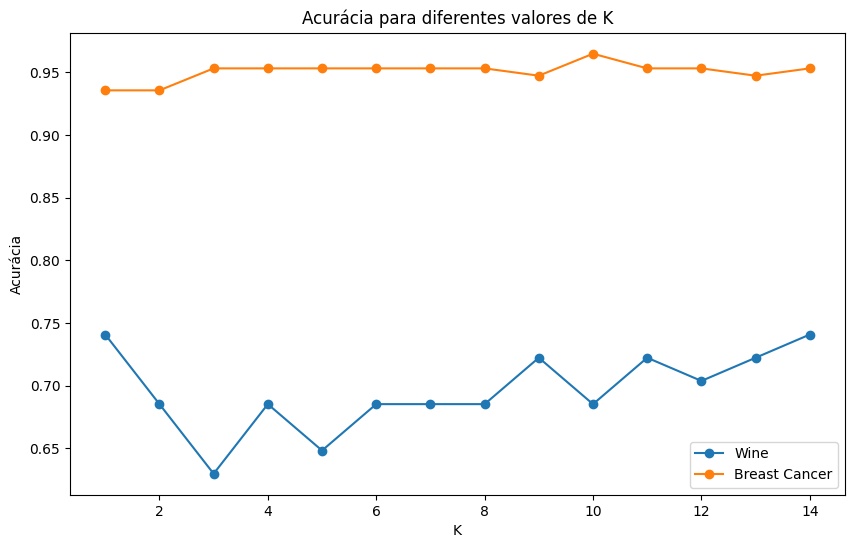

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(range_k, acuracias_wine, label='Wine', marker='o')
plt.plot(range_k, acuracias_cancer, label='Breast Cancer', marker='o')
plt.title('Acurácia para diferentes valores de K')
plt.xlabel('K')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

- O melhor valor de K para o dataset Breast Cancer é k=10. Mas desde o k=3, os valores de acurácia se mantem constantes.

- O melhor valor de k para o dataset Wine é k=14, pois apresenta a maior acurácia. E descartei o k=1, que também deu alto, porque o risco de ter overffiting é grande.

In [17]:
# Exercício 9

cabecalhos_mpg = ['displacement', 'mpg', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
url = "https://raw.githubusercontent.com/professortiagoinfnet/inteligencia_artificial/refs/heads/main/auto%2Bmpg/auto-mpg.csv"

df_mpg = pd.DataFrame(pd.read_csv(url, names=cabecalhos_mpg, sep=','))
df_mpg.head()

,displacement,mpg,cylinders,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,"chevrolet,chevelle,malibu"
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,"buick,skylark,320"
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,"plymouth,satellite"
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,"amc,rebel,sst"
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,"ford,torino"


In [19]:
df_mpg = df_mpg.drop(columns=['car_name'])
df_mpg.head(3)

,displacement,mpg,cylinders,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1


In [20]:
df_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   mpg           398 non-null    int64  
 2   cylinders     398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [21]:
df_mpg = df_mpg.dropna()
df_mpg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  392 non-null    float64
 1   mpg           392 non-null    int64  
 2   cylinders     392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 27.6 KB


In [23]:
X = df_mpg.drop(columns=['mpg'])
y = df_mpg['mpg']

In [24]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, train_size=0.7, random_state=250)

In [25]:
regressor_knn = KNeighborsRegressor(n_neighbors=5)

In [26]:
regressor_knn.fit(X_treino, y_treino)

KNeighborsRegressor()

In [27]:
y_pred = regressor_knn.predict(X_teste)

In [32]:
# Exercício 10

range_k = range(1, 11)

mae = []
mse = []

for k in range_k:
  regressor_knn = KNeighborsRegressor(n_neighbors=k)
  regressor_knn.fit(X_treino, y_treino)
  y_pred = regressor_knn.predict(X_teste)

  mae_resultados = mean_absolute_error(y_teste, y_pred)
  mse_resultados = mean_squared_error(y_teste, y_pred)

  mae.append(mae_resultados)
  mse.append(mse_resultados)

resultados = pd.DataFrame({
    "k": list(range_k),
    "MAE": mae,
    "MSE": mse
})

print(resultados)

    k       MAE       MSE
0   1  0.135593  0.254237
1   2  0.114407  0.154661
2   3  0.135593  0.180791
3   4  0.161017  0.198093
4   5  0.200000  0.221695
5   6  0.223164  0.234934
6   7  0.232446  0.244206
7   8  0.247881  0.250794
8   9  0.265537  0.270349
9  10  0.280508  0.288220


In [ ]:
# Exercício 11

# Para valores de k menores, como igual a 2, o modelo performou
# melhor, pois apresenta erros mais baixos. Quando os valores de k
# aumentam, os erros também aumentam, o que pode indicar underfitting
# do modelo.

# Em resumo, o modelo performou bem pelos erros bem baixos.